
The Brown Corpus is one of the earliest and most well-known collections of text used for linguistic research and natural language processing (NLP). It was compiled at Brown University in 1961 and represents a broad range of American English. The corpus is a carefully curated selection of approximately 1 million words from a wide variety of text sources, including newspapers, books, fiction, non-fiction, scientific writings, and more.

Here are some key details about the Brown Corpus:

Diversity: It covers a wide range of genres, with 500 samples of about 2,000 words each from 15 different text categories, such as news, editorial, religion, learned texts, fiction, adventure, romance, and humor.

Usage: The Brown Corpus is primarily used for linguistic research and NLP tasks, such as part-of-speech tagging, syntactic analysis, word frequency analysis, and building models like Word2Vec.

Influence: As one of the first large-scale linguistic corpora, it has influenced the development of many other corpora and remains a key resource for training and testing various NLP models.

Structure: It is tokenized and tagged with part-of-speech labels, making it ideal for tasks that require detailed linguistic information.

In the context of Word2Vec or other NLP models, the Brown Corpus provides a good variety of word usages, making it useful for training models that can understand different contexts in language.



In [2]:
!pip install gensim

  Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl.metadata (8.2 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl (24.0 MB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached scipy-1.13.1-cp312-cp312-win_amd64.whl (45.9 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)

   ---------------------------------------- 0/4 [smart-open]
   ---------------------------------------- 0/4 [smart-open]
   ---------------------------------------- 0/4 [smart-open]
   ---------------------------------------- 0/4 [smart-open]
  Attempting uninstall: numpy
   ---------------------------------------- 0/4 [smart-open]
    Found existing installation: numpy 2.1.3
   ---------------------------------------- 0/4 [smart-open]
   ---------- -----------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [3]:
# Word2Vec with Gensim Example

# Importing necessary libraries
import gensim
from gensim.models import Word2Vec
from nltk.corpus import brown
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import nltk

# Download necessary NLTK data
nltk.download('brown')
nltk.download('punkt')

# Load corpus (for demonstration, we use the Brown corpus from NLTK)
corpus = brown.sents()


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\cleme\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cleme\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
corpus

[['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.'], ['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.'], ...]

In [10]:

# Preprocessing: Simple tokenization (in this case, the corpus is already tokenized)
print("Sample Sentence:", corpus[20])


Sample Sentence: ['The', 'jury', 'said', 'it', 'found', 'the', 'court', '``', 'has', 'incorporated', 'into', 'its', 'operating', 'procedures', 'the', 'recommendations', "''", 'of', 'two', 'previous', 'grand', 'juries', ',', 'the', 'Atlanta', 'Bar', 'Association', 'and', 'an', 'interim', 'citizens', 'committee', '.']


In [9]:
corpus[0].shape

AttributeError: 'list' object has no attribute 'shape'

In [15]:

# Train Word2Vec model
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=2, workers=4)


In [16]:

# Save the model
model.save("word2vec_brown.model")


In [17]:

# Load the saved model
new_model = Word2Vec.load("word2vec_brown.model")


In [18]:

# Find words similar to 'money'
similar_words = new_model.wv.most_similar('money', topn=5)
print("\nWords most similar to 'money':", similar_words)



Words most similar to 'money': [('care', 0.9227120876312256), ('work', 0.8994835019111633), ('freedom', 0.8922446966171265), ('job', 0.889302134513855), ('ability', 0.8853945136070251)]


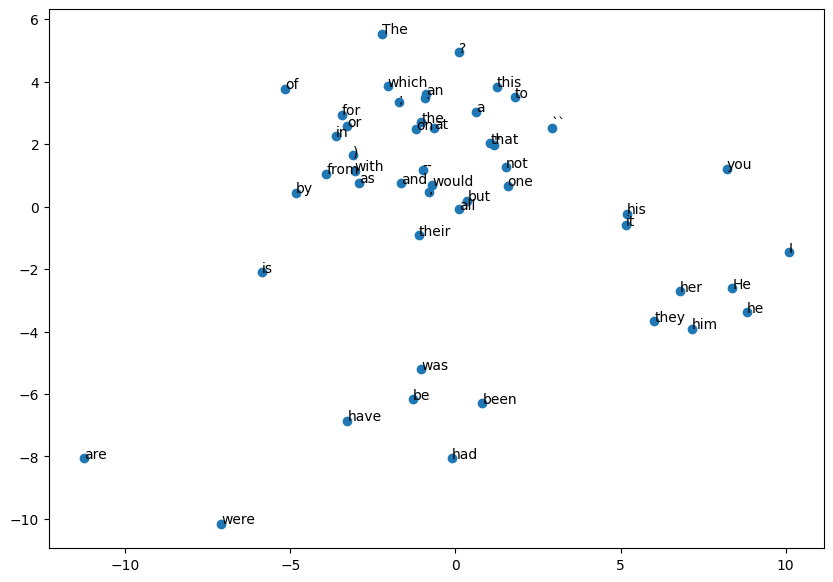

In [19]:

# Visualize the word embeddings using PCA
words = list(new_model.wv.key_to_index)[:50]  # Take the first 50 words
word_vectors = [new_model.wv[word] for word in words]

# Reduce the dimensions with PCA
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

# Plot the words in 2D space
plt.figure(figsize=(10, 7))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.show()


In [2]:
corpus

[['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.'], ['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.'], ...]

In [20]:
word1 = "pants"
word2 = "shirt"

vector1 = new_model.wv[word1] # Access the word vector using .wv
vector2 = new_model.wv[word2] # Access the word vector using .wv

In [21]:
vector1

array([-1.36849275e-02,  5.75260222e-02,  9.19978544e-02,  2.91425195e-02,
        3.13799903e-02, -9.12316367e-02,  6.86915293e-02,  1.40672803e-01,
       -3.14474031e-02, -3.24661322e-02, -2.49782912e-02, -2.04580098e-01,
        3.09335347e-02,  7.06940517e-02,  7.66625777e-02, -6.76738843e-02,
        3.78087955e-03, -2.99892183e-02, -1.38144819e-02, -9.40016583e-02,
        8.36803690e-02, -2.57910490e-02,  7.15136819e-04, -3.40466941e-04,
        1.04988003e-02, -9.28058475e-03, -6.29178435e-02,  2.46172138e-02,
       -3.28227393e-02, -1.07891932e-02,  8.10460970e-02, -6.68064579e-02,
        4.11243252e-02, -1.62642837e-01,  3.71461920e-03,  1.29800579e-02,
        4.66479510e-02,  6.22688979e-03, -1.15448385e-01, -1.25777990e-01,
        3.86650600e-02, -1.03703499e-01, -1.33481137e-02, -1.56405978e-02,
       -2.07682811e-02,  1.93255150e-03, -6.36254996e-02, -9.30868555e-03,
       -7.26446733e-02,  9.18304548e-02,  1.56568773e-02, -8.02214220e-02,
       -8.31022337e-02, -

In [22]:
vector2

array([-0.03449506,  0.15792464,  0.1197777 ,  0.0912106 , -0.03883255,
       -0.2454124 ,  0.19378446,  0.45802274, -0.15570883, -0.18751954,
       -0.05473926, -0.40416333,  0.05652444,  0.13044932,  0.21843462,
       -0.21222512,  0.02410077, -0.02144601, -0.10108753, -0.22464338,
        0.26945922, -0.07614029,  0.05656413,  0.05568847,  0.04707281,
       -0.05856724, -0.15596028,  0.02291062, -0.16873465,  0.0020867 ,
        0.09826462, -0.14794803,  0.15910847, -0.37494877, -0.00640621,
        0.10868426,  0.09431379,  0.08682992, -0.29704183, -0.18415976,
        0.10714343, -0.28620315, -0.0678254 , -0.04031297, -0.03979988,
        0.03295501, -0.11024246, -0.06022218, -0.18203652,  0.17366049,
        0.01521438, -0.255317  , -0.26296788, -0.19853282,  0.17339547,
        0.0105582 ,  0.10993705,  0.04449093, -0.117116  , -0.06116149,
       -0.04429832,  0.04734334,  0.06100675, -0.04497439, -0.22841054,
        0.3110778 ,  0.01249309,  0.2743989 , -0.23332117,  0.31

In [23]:
# Calculate cosine similarity between the two words
similarity = new_model.wv.similarity(word1, word2)
print(f"Cosine similarity between '{word1}' and '{word2}': {similarity}")

Cosine similarity between 'pants' and 'shirt': 0.9413018822669983


In [25]:
# Calculate cosine similarity between the two words
similarity = new_model.wv.similarity('garbage', 'live')
print(f"Cosine similarity: {similarity}")

Cosine similarity: 0.6708903312683105


Pass Word2Vec embeddings into an LSTM model as input.

Using pre-trained word embeddings like Word2Vec in an LSTM is a common practice for NLP tasks like text classification, named entity recognition, or sentiment analysis.

Overview:
Each word in your input sequence is converted into its corresponding Word2Vec embedding.
These word embeddings are passed as a batch of inputs to the LSTM.
The LSTM processes the sequence and can output a prediction (for classification, sequence-to-sequence, etc.).

In [26]:
import gensim.downloader as api
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [27]:

# Load pre-trained Word2Vec model
word2vec_model = api.load('word2vec-google-news-300')


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [28]:

# Example sentences
sentences = [
    "I love machine learning",
    "The cat is being a bit naughty",
    "Dogs are loyal animals"
    "I will pass my final exam with good marks",
    "I am going to enjoy the weekend with my friends",
    "The weather is nice today",
    "Dr Clements evil teacher and he is very strict",
    "The movie was fantastic and I really enjoyed it",
    "This fruit smells really bad and tastes awful"
]

# Preprocessing: Tokenize and get word embeddings for each sentence
def get_word2vec_embeddings(sentence, word2vec_model, embedding_dim=300):
    embedding_matrix = []
    for word in sentence.split():
        if word in word2vec_model:
            embedding_matrix.append(word2vec_model[word])
        else:
            embedding_matrix.append(np.zeros(embedding_dim))  # Unknown words are zeros
    return np.array(embedding_matrix)

# Convert each sentence into word embeddings
embedded_sentences = [get_word2vec_embeddings(sentence, word2vec_model) for sentence in sentences]

# Pad the sequences to ensure equal length (for batching)
max_sequence_length = max([embedding.shape[0] for embedding in embedded_sentences])
padded_sentences = pad_sequences(embedded_sentences, maxlen=max_sequence_length, padding='post', dtype='float32')

# Build an LSTM model
model = Sequential()

# LSTM layer (Note: input_shape is set to the size of the embedding (300) and the max sequence length)
model.add(LSTM(128, input_shape=(max_sequence_length, 300), return_sequences=False))

# Add a Dense layer for binary classification (e.g., sentiment analysis)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()

# Example labels (for binary classification task)
labels = np.array([1, 0, 1, 1 ,1, 1, 0, 1, 0])  # Example: 1=positive sentiment, 0=negative sentiment

# Train the model
model.fit(padded_sentences, labels, epochs=10, batch_size=1, verbose=1)


c:\Users\cleme\code\SEAS6414\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,777 (858.50 KB)

 Trainable params: 219,777 (858.50 KB)

 Non-trainable params: 0 (0.00 B)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 8
'y' sizes: 9


In [ ]:
test_sentences = [
    "Grocery shopping is a hassle",
    "Passing exams means I get to go on vacation",
    "I will use machine learning to solve real-world problems",
]

In [35]:
# Convert each sentence into word embeddings
embedded_test_sentences = [get_word2vec_embeddings(sentence, word2vec_model) for sentence in test_sentences]

# Pad the sequences to ensure equal length (for batching)
padded_test_sentences = pad_sequences(embedded_test_sentences, maxlen=max_sequence_length, padding='post', dtype='float32')

In [ ]:
results = model.predict(padded_test_sentences)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0.83585155],
       [0.3396184 ],
       [0.95021504]], dtype=float32)

In [ ]:
rounded_results
print(rounded_results)
print(rounded_results) = np.round(results).astype(int)rounded_results = = np.round(results).astype(int) np.round(results).astype(int)